# 🌾 Crop Recommendation Model
Base dataset: **CropDataset-Enhanced.csv** (region-wise soil N/P/K/pH composition + crops grown)
Enrichment dataset: **Final_Integrated_Dataset.csv** (satellite/weather features — used in a bonus section)

**Approach**: Har region me kaunse crops ugte hain (multi-label) predict karta hai based on us region ki soil N/P/K/pH % composition. Isko hum ek **multi-label classification** problem ki tarah treat kar rahe hain (ek region me multiple crops ho sakte hain), RandomForest ke saath.

> Upload both CSV files when prompted below (or place them in the Colab working directory).

## 1. Setup

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib joblib


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, f1_score, classification_report
import joblib

pd.set_option('display.max_columns', 50)


## 2. Load Data
Agar files already Colab session me nahi hain to upload karne ke liye niche wala cell chalao.

In [ ]:
CROP_FILE = 'CropDataset-Enhanced.csv'
ENV_FILE  = 'Final_Integrated_Dataset.csv'

if not (os.path.exists(CROP_FILE) and os.path.exists(ENV_FILE)):
    try:
        from google.colab import files
        print("Please upload CropDataset-Enhanced.csv and Final_Integrated_Dataset.csv")
        uploaded = files.upload()
    except ImportError:
        print("Not running in Colab and files not found locally — place them in this directory.")


Please upload CropDataset-Enhanced.csv and Final_Integrated_Dataset.csv


Saving CropDataset-Enhanced.csv to CropDataset-Enhanced.csv
Saving Final_Integrated_Dataset.csv to Final_Integrated_Dataset.csv


In [ ]:
crop_df = pd.read_csv(CROP_FILE)
env_df  = pd.read_csv(ENV_FILE)

print("CropDataset-Enhanced:", crop_df.shape)
print("Final_Integrated_Dataset:", env_df.shape)
crop_df.head()


CropDataset-Enhanced: (730, 23)
Final_Integrated_Dataset: (97, 12)


,Address,Status geocode,Formatted address,Latitude,Longitude,Type,Location Type,Country,Region,Crop,Nitrogen - High,Nitrogen - Medium,Nitrogen - Low,Phosphorous - High,Phosphorous - Medium,Phosphorous - Low,Potassium - High,Potassium - Medium,Potassium - Low,pH - Acidic,pH - Neutral,pH - Alkaline,
0,Ahilya nagar,Ok,"Ahilya Nagar, Maharashtra, India",19.094829,74.747979,"locality, political",APPROXIMATE,India,Maharashtra,"Sugarcane, Bajra (Pearl Millet), Wheat, Cotton...",0.03%,3.55%,96.42%,74.02%,21.09%,4.89%,39.15%,42.81%,18.04%,0.11%,96.02%,3.87%,NaN
1,Akola,Ok,"Akola, Maharashtra, India",20.700216,77.008168,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Soybean, Jowar (Sorghum), Wheat, Tur (...",0.05%,0.28%,99.67%,68.52%,28.76%,2.72%,84.11%,14.74%,1.14%,0%,95.62%,4.38%,NaN
2,Amravati,Ok,"Amravati, Maharashtra, India",20.931982,77.752304,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Soybean, Jowar (Sorghum), Wheat, Tur (...",0.10%,0.87%,99.03%,9.76%,28.19%,62.05%,80.88%,6.25%,12.87%,13.44%,84.55%,2.01%,NaN
3,"Chhatrapati Sambhaji Nagar, Maharashtra",Ok,"Chhatrapati Sambhaji Nagar, Maharashtra, India",19.875754,75.339320,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Bajra (Pearl Millet), Wheat, Sugarcane...",0.03%,1.91%,98.07%,61.51%,30.92%,7.57%,73.23%,24.86%,1.91%,0%,90.48%,9.52%,NaN
4,"Beed, Maharashtra",Ok,"Beed, Maharashtra 431122, India",18.990088,75.753132,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Bajra (Pearl Millet), Wheat, Sugarcane...",2.19%,36.57%,61.25%,13.78%,75.24%,10.98%,52.74%,42.98%,4.28%,0.11%,90.24%,9.65%,NaN


## 3. Clean the Base Crop Dataset
- Drop empty trailing column
- Drop rows with missing soil composition
- Convert `"12.34%"` style strings → floats (0–1 scale)

In [ ]:
crop_df = crop_df.drop(columns=[c for c in crop_df.columns if c.strip() == ''])
crop_df = crop_df.dropna(subset=['Nitrogen - High']).reset_index(drop=True)

PCT_COLS = ['Nitrogen - High','Nitrogen - Medium','Nitrogen - Low',
            'Phosphorous - High','Phosphorous - Medium','Phosphorous - Low',
            'Potassium - High','Potassium - Medium','Potassium - Low',
            'pH - Acidic','pH - Neutral','pH - Alkaline']

for c in PCT_COLS:
    crop_df[c] = crop_df[c].astype(str).str.replace('%', '', regex=False).astype(float) / 100.0

print(f"Rows after cleaning: {len(crop_df)}")
crop_df[PCT_COLS].describe().loc[['min','max']]


Rows after cleaning: 695


,Nitrogen - High,Nitrogen - Medium,Nitrogen - Low,Phosphorous - High,Phosphorous - Medium,Phosphorous - Low,Potassium - High,Potassium - Medium,Potassium - Low,pH - Acidic,pH - Neutral,pH - Alkaline
min,0.0000,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0000,0.0,0.0000
max,0.8838,1.0,1.0,1.0,1.0,1.0,0.9969,0.9987,1.0,0.9906,1.0,0.8589


## 4. Normalize Crop Names
The `Crop` column is a messy comma-separated free-text field (synonyms, stray fragments from parsing). We normalize common synonyms and drop junk fragments so the label space is usable.

In [ ]:
SYNONYMS = {
    'bajra (pearl millet)': 'bajra', 'jowar (sorghum)': 'jowar',
    'tur (pigeon pea)': 'tur', 'arhar (pigeon pea)': 'tur', 'arhar': 'tur',
    'red gram (tur)': 'tur', 'red gram': 'tur',
    'rajma (kidney beans)': 'rajma', 'ragi (finger millet)': 'ragi',
    'finger millet (ragi)': 'ragi', 'mandua (finger millet)': 'ragi', 'mandua': 'ragi',
    'lentil (masoor)': 'lentil', 'lentils': 'lentil', 'soyabean': 'soybean',
    'paddy': 'rice', 'basmati rice': 'rice', 'grapes': 'grape', 'apples': 'apple',
    'apple (high yield)': 'apple', 'oranges': 'orange', 'potatoes': 'potato',
    'tomatoes': 'tomato', 'cashewnut': 'cashew', 'vegetables (tomato)': 'vegetables',
    'citrus fruits': 'citrus', 'millets': 'millet', 'minor millets': 'millet',
    'oilseeds\u200b': 'oilseeds', 'cotton\u200b': 'cotton', 'mustard\u200b': 'mustard',
    'garlic\u200b': 'garlic', 'buckwheat\u200b': 'buckwheat',
}
JUNK = {
    'and gram','and maize','and mustard.','and oilseeds','and paddy','and pulses',
    'and soybean','and wheat','boro)','herbs)',
    'urban area; limited agriculture (terrace farming: vegetables',
    'urban farming: vegetables','greens (urban/peri-urban)','paddy (aman',
    'fruits like chikoo (sapota) and mango','fruits like mango and cashew',
    'fruits like mango and chikoo (sapota)','flowers (like chrysanthemum)',
    'mango (notably alphonso)',
}

def clean_crop_list(raw):
    out = []
    for c in str(raw).split(','):
        c = c.replace('\u200b', '').strip().lower().rstrip('.')
        if not c or c in JUNK:
            continue
        out.append(SYNONYMS.get(c, c))
    return sorted(set(out))

crop_df['CropList'] = crop_df['Crop'].apply(clean_crop_list)

all_crops = pd.Series([c for lst in crop_df['CropList'] for c in lst])
print("Unique crops after cleaning:", all_crops.nunique())
all_crops.value_counts().head(20)


Unique crops after cleaning: 90


,count
rice,433
wheat,277
maize,233
mustard,196
sugarcane,130
pulses,106
cotton,105
vegetables,90
groundnut,89
ginger,71


## 5. Build the Multi-Label Target
Rare crops (appearing in very few regions) are dropped so the model has enough examples per class to actually learn something. Threshold is adjustable.

In [ ]:
MIN_COUNT = 15  # a crop must appear in at least this many regions to be kept as a target label

crop_counts = all_crops.value_counts()
keep_crops = set(crop_counts[crop_counts >= MIN_COUNT].index)

crop_df['CropListFiltered'] = crop_df['CropList'].apply(lambda lst: [c for c in lst if c in keep_crops])
crop_df = crop_df[crop_df['CropListFiltered'].map(len) > 0].reset_index(drop=True)

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(crop_df['CropListFiltered'])
X = crop_df[PCT_COLS].values

print(f"Rows used for training: {len(crop_df)}")
print(f"Feature matrix: {X.shape}, Target matrix: {Y.shape}")
print(f"Crop labels ({len(mlb.classes_)}): {list(mlb.classes_)}")


Rows used for training: 689
Feature matrix: (689, 12), Target matrix: (689, 26)
Crop labels (26): ['apple', 'bajra', 'banana', 'barley', 'coconut', 'cotton', 'ginger', 'gram', 'groundnut', 'jowar', 'jute', 'maize', 'millet', 'mustard', 'oilseeds', 'pineapple', 'potato', 'pulses', 'ragi', 'rice', 'soybean', 'sugarcane', 'tur', 'turmeric', 'vegetables', 'wheat']


## 6. Train the Model
RandomForest wrapped in `MultiOutputClassifier` — one classifier per crop, sharing the same soil-composition features.

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print(f"Hamming loss : {hamming_loss(Y_test, Y_pred):.3f}  (lower is better)")
print(f"Micro F1     : {f1_score(Y_test, Y_pred, average='micro'):.3f}")
print(f"Macro F1     : {f1_score(Y_test, Y_pred, average='macro'):.3f}")


Hamming loss : 0.102  (lower is better)
Micro F1     : 0.490
Macro F1     : 0.245


In [ ]:
print(classification_report(Y_test, Y_pred, target_names=mlb.classes_, zero_division=0))


              precision    recall  f1-score   support

       apple       0.00      0.00      0.00         3
       bajra       0.60      0.33      0.43         9
      banana       0.00      0.00      0.00         7
      barley       0.00      0.00      0.00         6
     coconut       0.67      0.40      0.50         5
      cotton       0.60      0.15      0.24        20
      ginger       1.00      0.18      0.31        11
        gram       0.00      0.00      0.00        11
   groundnut       0.50      0.06      0.11        16
       jowar       1.00      0.17      0.29         6
        jute       0.50      0.10      0.17        10
       maize       0.66      0.40      0.49        48
      millet       0.50      0.11      0.18         9
     mustard       0.63      0.56      0.59        34
    oilseeds       0.67      0.33      0.44         6
   pineapple       0.00      0.00      0.00         2
      potato       0.00      0.00      0.00         6
      pulses       1.00    

## 6B. Confusion Matrix & Subset (Exact-Match) Accuracy
Multi-label problem mein ek single confusion matrix nahi banti jaisa normal classification mein hoti hai — kyunki har region ke paas ek saath multiple crop-labels (yes/no) hote hain, single 'true class' nahi. Iske liye har crop ka apna 2x2 (Grown vs Not-Grown) confusion matrix nikaalte hain, phir unko jodkar ek overall/aggregate confusion matrix banate hain. Saath hi, **Label Accuracy** (jo humne ab tak use kiya, 1 - Hamming Loss) aur **Subset/Exact-Match Accuracy** (poora region ka pura crop-set sahi predict hua ya nahi) dono nikaalte hain — dono alag cheez batate hain.

Aggregate confusion matrix across all 26 crop labels:
  True Negatives  (correctly said 'not grown'): 3046
  False Positives (wrongly said 'grown')       : 90
  False Negatives (missed an actual crop)      : 276
  True Positives  (correctly said 'grown')     : 176


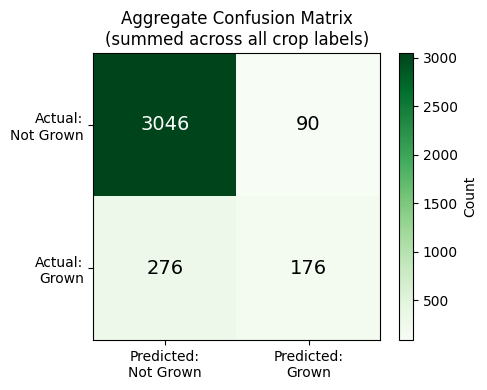

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

# Per-crop confusion matrices, shape: (n_crops, 2, 2) -> each is [[TN, FP], [FN, TP]]
mcm = multilabel_confusion_matrix(Y_test, Y_pred)

# Aggregate (micro-averaged) confusion matrix -- sum across all crop labels
agg = mcm.sum(axis=0)
tn, fp, fn, tp = agg[0, 0], agg[0, 1], agg[1, 0], agg[1, 1]

print(f"Aggregate confusion matrix across all {len(mlb.classes_)} crop labels:")
print(f"  True Negatives  (correctly said 'not grown'): {tn}")
print(f"  False Positives (wrongly said 'grown')       : {fp}")
print(f"  False Negatives (missed an actual crop)      : {fn}")
print(f"  True Positives  (correctly said 'grown')     : {tp}")

cm_display = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(5, 4))
plt.imshow(cm_display, cmap='Greens')
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(cm_display[i, j]), ha='center', va='center', fontsize=14,
                 color='white' if cm_display[i, j] > cm_display.max() / 2 else 'black')
plt.xticks([0, 1], ['Predicted:\nNot Grown', 'Predicted:\nGrown'])
plt.yticks([0, 1], ['Actual:\nNot Grown', 'Actual:\nGrown'])
plt.title('Aggregate Confusion Matrix\n(summed across all crop labels)')
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()


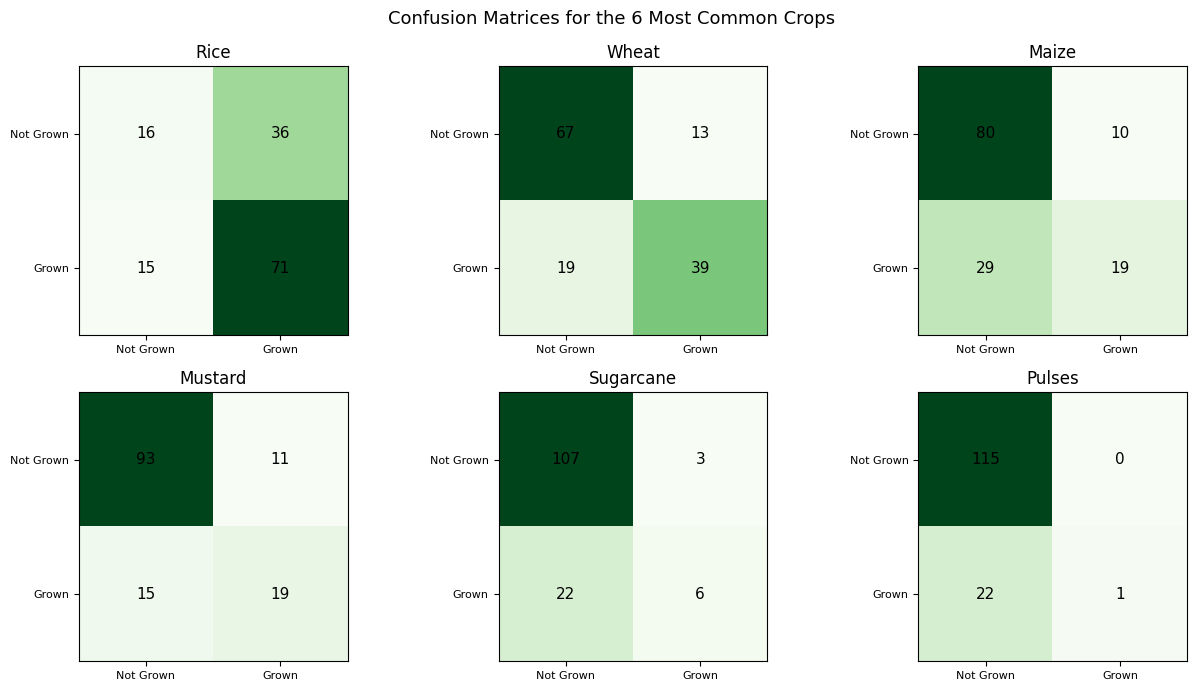

In [ ]:
# Confusion matrices for the 6 most common crops individually
top6_crops = crop_counts.head(6).index.tolist()
top6_idx = [list(mlb.classes_).index(c) for c in top6_crops if c in mlb.classes_]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, idx_c in zip(axes.flatten(), top6_idx):
    cm = mcm[idx_c]
    crop_name = mlb.classes_[idx_c]
    ax.imshow(cm, cmap='Greens')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Not Grown', 'Grown'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Not Grown', 'Grown'], fontsize=8)
    ax.set_title(crop_name.title())
plt.suptitle('Confusion Matrices for the 6 Most Common Crops', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Two different notions of "accuracy" for a multi-label problem
label_accuracy = 1 - hamming_loss(Y_test, Y_pred)
subset_accuracy = (Y_pred == Y_test).all(axis=1).mean()

print(f"Label Accuracy   (per-crop-label correctness) : {label_accuracy:.3f}")
print(f"Subset Accuracy  (whole region's crop-set exactly right): {subset_accuracy:.3f}")


Label Accuracy   (per-crop-label correctness) : 0.898
Subset Accuracy  (whole region's crop-set exactly right): 0.058


## 7. Feature Importance
Which soil property drives predictions most, averaged across all crop classifiers.

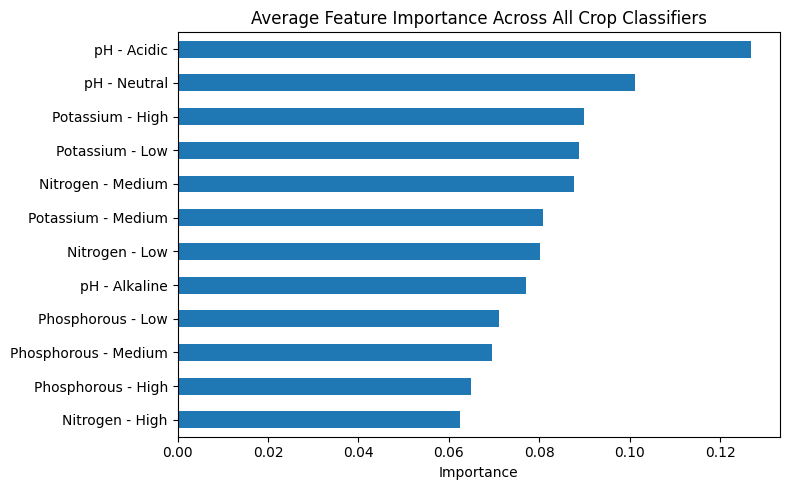

In [ ]:
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
imp_series = pd.Series(importances, index=PCT_COLS).sort_values()

plt.figure(figsize=(8,5))
imp_series.plot(kind='barh')
plt.title('Average Feature Importance Across All Crop Classifiers')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 8. Recommendation Function
Given a region's dominant soil levels (High/Medium/Low for N, P, K and Acidic/Neutral/Alkaline for pH), return the top predicted crops with confidence scores.

> Note: this is an approximation — the training data represents % of samples in each bucket per region, so a single dominant-level query is treated as a 100%-in-that-bucket profile.

In [ ]:
def recommend_crops(nitrogen, phosphorous, potassium, ph, top_k=5):
    """
    nitrogen, phosphorous, potassium: 'High' | 'Medium' | 'Low'
    ph: 'Acidic' | 'Neutral' | 'Alkaline'
    """
    row = {c: 0.0 for c in PCT_COLS}
    row[f'Nitrogen - {nitrogen}'] = 1.0
    row[f'Phosphorous - {phosphorous}'] = 1.0
    row[f'Potassium - {potassium}'] = 1.0
    row[f'pH - {ph}'] = 1.0
    xq = np.array([[row[c] for c in PCT_COLS]])

    probs = []
    for est in model.estimators_:
        p = est.predict_proba(xq)[0]
        probs.append(p[1] if len(p) > 1 else 0.0)
    probs = np.array(probs)

    order = np.argsort(probs)[::-1][:top_k]
    return [(mlb.classes_[i], round(float(probs[i]), 3)) for i in order]


# Example usage
print("High N, Medium P, Low K, Neutral pH  ->", recommend_crops('High', 'Medium', 'Low', 'Neutral'))
print("Low N, High P, High K, Acidic pH     ->", recommend_crops('Low', 'High', 'High', 'Acidic'))


High N, Medium P, Low K, Neutral pH  -> [('wheat', 0.683), ('rice', 0.643), ('maize', 0.57), ('sugarcane', 0.41), ('cotton', 0.31)]
Low N, High P, High K, Acidic pH     -> [('rice', 0.617), ('maize', 0.467), ('mustard', 0.26), ('pulses', 0.243), ('sugarcane', 0.213)]


## 8B. Charts to Present

**Chart 1 — India ke regions me sabse zyada kaunse crops ugte hain**

"Humare dataset ke 695 regions me se, rice sabse zyada (433 regions me) aur wheat doosre number pe (277 regions me) uga jaata hai."*

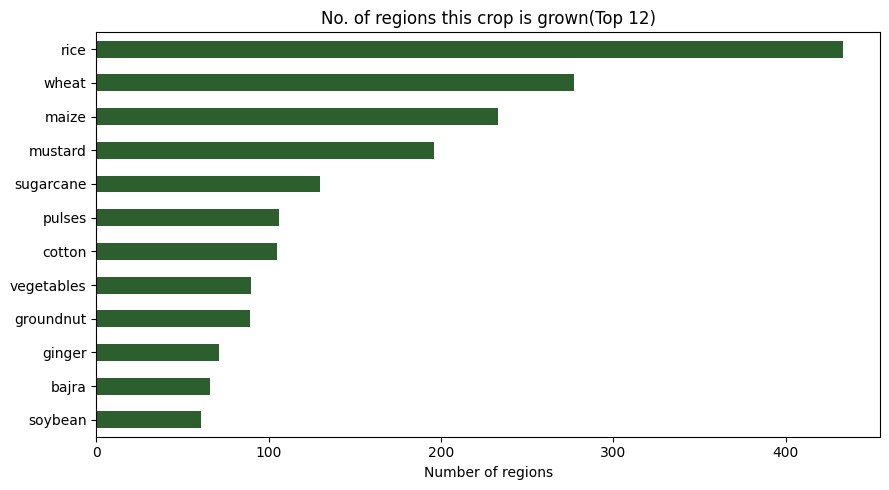

In [ ]:
top_crops_chart = crop_counts.head(12).sort_values()

plt.figure(figsize=(9,5))
top_crops_chart.plot(kind='barh', color='#2C5F2D')
plt.title('No. of regions this crop is grown(Top 12)')
plt.xlabel('Number of regions')
plt.tight_layout()
plt.show()


**Chart 2 — Model kitna accurate hai (overall)**

Hamara model test data pe ~90% label accuracy deta hai, aur micro F1-score 0.49 hai — jo ek chhote (695-row) dataset ke liye ek decent baseline hai."*

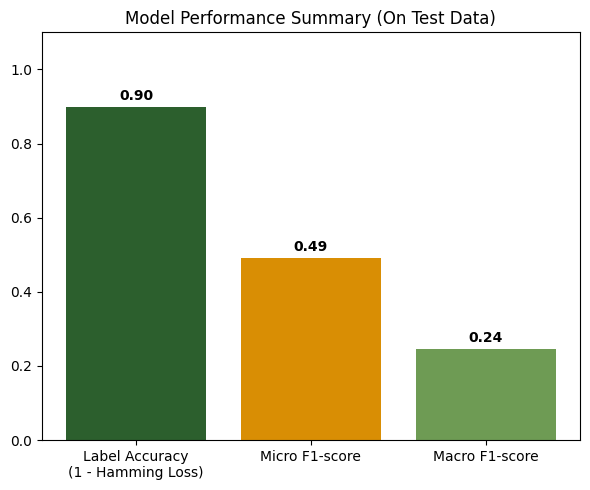

In [ ]:
h = hamming_loss(Y_test, Y_pred)
mi = f1_score(Y_test, Y_pred, average='micro')
ma = f1_score(Y_test, Y_pred, average='macro')

plt.figure(figsize=(6,5))
bars = plt.bar(
    ['Label Accuracy\n(1 - Hamming Loss)', 'Micro F1-score', 'Macro F1-score'],
    [1-h, mi, ma],
    color=['#2C5F2D', '#D98E04', '#6E9B54']
)
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{b.get_height():.2f}',
              ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Model Performance Summary (On Test Data)')
plt.tight_layout()
plt.show()


**Chart 3 — Kaunse crops model sabse accurately predict karta hai**

"Rice aur wheat jaise crops jinke paas zyada training data tha, unko model bahut accurately predict karta hai (F1 ~0.7+). Kam-data wale crops abhi utne accurate nahi hain."*

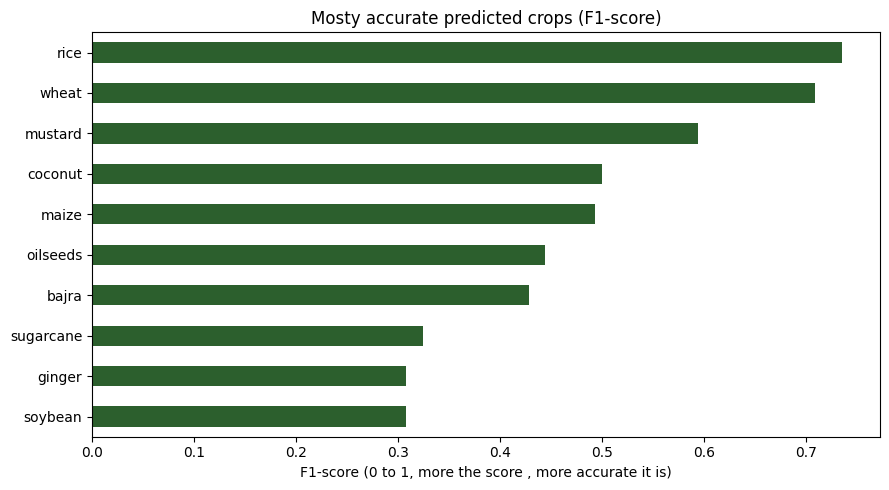

In [ ]:
report = classification_report(Y_test, Y_pred, target_names=mlb.classes_, zero_division=0, output_dict=True)
per_crop_f1 = pd.Series({k: v['f1-score'] for k, v in report.items() if k in mlb.classes_})
top10_f1 = per_crop_f1.sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
top10_f1.sort_values().plot(kind='barh', color='#2C5F2D')
plt.title('Mosty accurate predicted crops (F1-score)')
plt.xlabel('F1-score (0 to 1, more the score , more accurate it is)')
plt.tight_layout()
plt.show()


**Chart 4 — Case Study: kisi ek region ke liye actual vs predicted crops**

"Muzaffarnagar ke liye, jo 4 crops actually wahan ugte hain (sugarcane, wheat, mustard, potato), model unhi 4 ko top prediction me deta hai — dark green bars matlab actual crop se match hua."*

Niche `case_study_chart("kisi bhi region ka naam")` call karke koi bhi region check kar sakte ho — jaise `case_study_chart("Karnal")` ya `case_study_chart("Shamli")`.

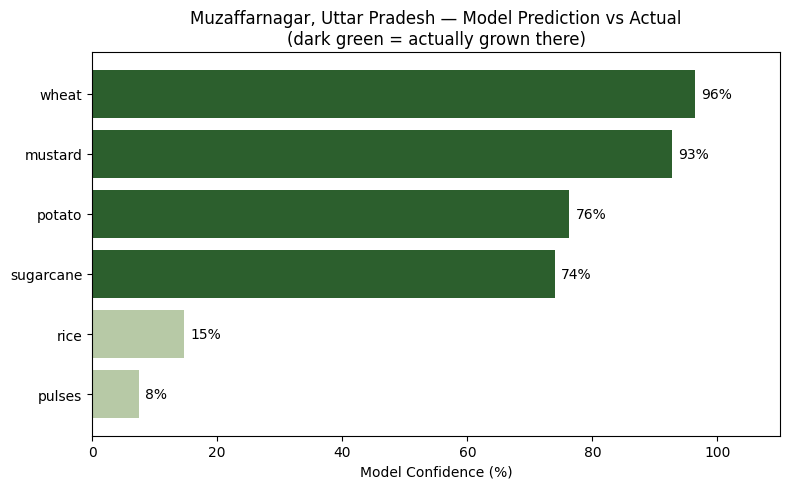

Actual crops (dataset): ['mustard', 'potato', 'sugarcane', 'wheat']
Model's top predictions: [('wheat', np.float64(0.96)), ('mustard', np.float64(0.93)), ('potato', np.float64(0.76)), ('sugarcane', np.float64(0.74)), ('rice', np.float64(0.15)), ('pulses', np.float64(0.08))]


In [ ]:
def case_study_chart(region_substring, top_k=6):
    row = crop_df[crop_df['Address'].str.contains(region_substring, case=False, na=False)]
    if len(row) == 0:
        print("Region not found — check spelling")
        return
    row = row.iloc[0]
    xq = row[PCT_COLS].values.reshape(1, -1).astype(float)

    probs = []
    for est in model.estimators_:
        p = est.predict_proba(xq)[0]
        probs.append(p[1] if len(p) > 1 else 0.0)
    probs = np.array(probs)

    order = np.argsort(probs)[::-1][:top_k]
    pred_crops = [mlb.classes_[i] for i in order]
    pred_probs = [probs[i] for i in order]
    actual = set(clean_crop_list(row['Crop']))

    colors = ['#2C5F2D' if c in actual else '#B7C9A6' for c in pred_crops]
    plt.figure(figsize=(8, 5))
    bars = plt.barh(pred_crops[::-1], [p * 100 for p in pred_probs[::-1]], color=colors[::-1])
    for b in bars:
        plt.text(b.get_width() + 1, b.get_y() + b.get_height() / 2, f'{b.get_width():.0f}%', va='center')
    plt.xlabel('Model Confidence (%)')
    plt.title(f"{row['Address']} \u2014 Model Prediction vs Actual\n(dark green = actually grown there)")
    plt.xlim(0, 110)
    plt.tight_layout()
    plt.show()

    print("Actual crops (dataset):", sorted(actual))
    print("Model's top predictions:", list(zip(pred_crops, [round(p, 2) for p in pred_probs])))


case_study_chart("Muzaffarnagar")


## 9. Model Comparison: RandomForest vs Other Algorithms
Same `X_train`/`X_test`/`Y_train`/`Y_test` split (Section 6) used across every model, so the comparison is apples-to-apples. Har model ek `MultiOutputClassifier` ke andar wrap hai — same multi-label setup jaisa RandomForest ke liye kiya tha.

In [ ]:
!pip install -q xgboost


In [ ]:
import time
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models_to_compare = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}

comparison_results = []

for name, base_model in models_to_compare.items():
    start = time.time()
    clf = MultiOutputClassifier(base_model)
    clf.fit(X_train, Y_train)
    Y_pred_cmp = clf.predict(X_test)
    elapsed = time.time() - start

    h = hamming_loss(Y_test, Y_pred_cmp)
    mi = f1_score(Y_test, Y_pred_cmp, average='micro', zero_division=0)
    ma = f1_score(Y_test, Y_pred_cmp, average='macro', zero_division=0)

    comparison_results.append({
        'Model': name,
        'Label Accuracy (1-Hamming)': round(1 - h, 3),
        'Micro F1': round(mi, 3),
        'Macro F1': round(ma, 3),
        'Train+Predict Time (s)': round(elapsed, 2)
    })
    print(f"{name:15s} | Label Acc: {1-h:.3f} | Micro F1: {mi:.3f} | Macro F1: {ma:.3f} | Time: {elapsed:.2f}s")

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
comparison_df


Decision Tree   | Label Acc: 0.845 | Micro F1: 0.396 | Macro F1: 0.230 | Time: 0.26s
KNN             | Label Acc: 0.887 | Micro F1: 0.459 | Macro F1: 0.233 | Time: 0.11s
SVM             | Label Acc: 0.721 | Micro F1: 0.366 | Macro F1: 0.296 | Time: 1.27s
Random Forest   | Label Acc: 0.898 | Micro F1: 0.490 | Macro F1: 0.245 | Time: 31.51s
XGBoost         | Label Acc: 0.893 | Micro F1: 0.500 | Macro F1: 0.307 | Time: 2.12s


,Label Accuracy (1-Hamming),Micro F1,Macro F1,Train+Predict Time (s)
Model,,,,
Decision Tree,0.845,0.396,0.230,0.26
KNN,0.887,0.459,0.233,0.11
SVM,0.721,0.366,0.296,1.27
Random Forest,0.898,0.490,0.245,31.51
XGBoost,0.893,0.500,0.307,2.12


**Chart — Model Comparison**
"Humne RandomForest ko 4 aur algorithms (Decision Tree, KNN, SVM, XGBoost) ke against test kiya — same train/test split pe — taaki pata chale RandomForest fair comparison me bhi best choice hai ya nahi."*

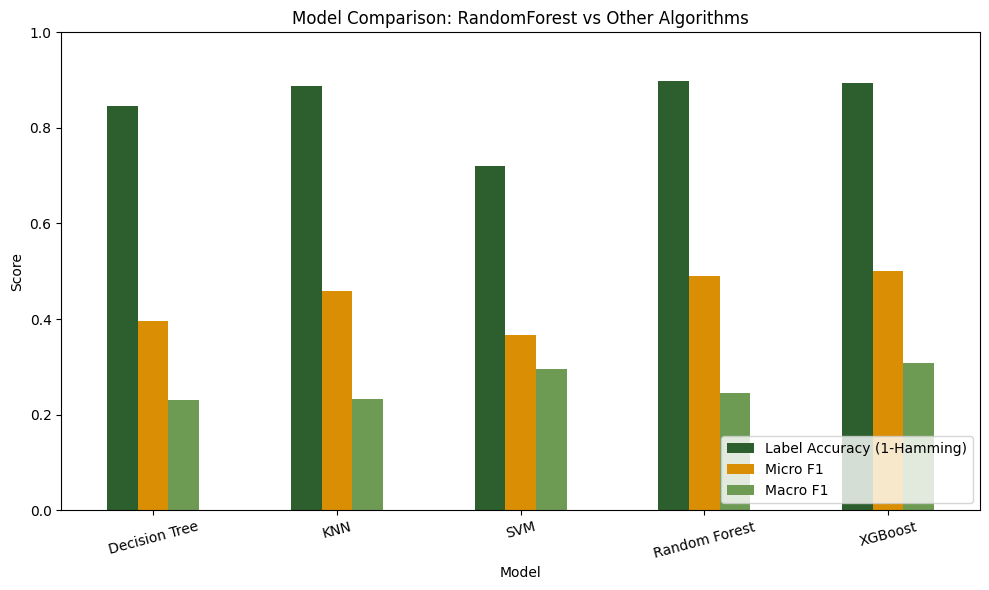

In [ ]:
comparison_df[['Label Accuracy (1-Hamming)', 'Micro F1', 'Macro F1']].plot(
    kind='bar', figsize=(10, 6), color=['#2C5F2D', '#D98E04', '#6E9B54']
)
plt.title('Model Comparison: RandomForest vs Other Algorithms')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 9B. Bonus: TabNet (Deep Learning for Tabular Data)
TabNet ek neural network architecture hai jo specifically tabular data ke liye bani hai (Arik & Pfister, Google, 2019). Sequential attention se har step pe important features select karta hai — decision tree jaisa behavior, but gradient descent se learned. Note: TabNet generally large datasets (1000s-millions rows) pe better perform karta hai; hamare 695-region dataset pe tree-based models (RF/XGBoost) ke jeetne ka chance zyada hai — but comparison ke liye try karte hain, jaisa mentor ne suggest kiya.

`TabNetMultiTaskClassifier` use kar rahe hain — har crop ek separate binary classification 'task' ban jata hai, jo hamare multi-label setup ke liye exactly designed hai.

In [ ]:
!pip install -q pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

X_train_np = np.array(X_train, dtype=np.float32)
X_test_np = np.array(X_test, dtype=np.float32)
Y_train_np = np.array(Y_train, dtype=np.int64)
Y_test_np = np.array(Y_test, dtype=np.int64)

start = time.time()
tabnet_clf = TabNetMultiTaskClassifier(
    n_d=8, n_a=8, n_steps=3,
    seed=42, verbose=0
)
tabnet_clf.fit(
    X_train=X_train_np, y_train=Y_train_np,
    eval_set=[(X_test_np, Y_test_np)],
    max_epochs=100, patience=15, batch_size=32
)
elapsed = time.time() - start

# predict() returns a list of arrays, one per crop/task -> stack into (n_samples, n_crops)
tabnet_preds_list = tabnet_clf.predict(X_test_np)
Y_pred_tabnet = np.stack(tabnet_preds_list, axis=1).astype(int)
Y_test_np = Y_test_np.astype(int)

h = hamming_loss(Y_test_np, Y_pred_tabnet)
mi = f1_score(Y_test_np, Y_pred_tabnet, average='micro', zero_division=0)
ma = f1_score(Y_test_np, Y_pred_tabnet, average='macro', zero_division=0)

print(f"{'TabNet':15s} | Label Acc: {1-h:.3f} | Micro F1: {mi:.3f} | Macro F1: {ma:.3f} | Time: {elapsed:.2f}s")

comparison_df.loc['TabNet'] = {
    'Label Accuracy (1-Hamming)': round(1 - h, 3),
    'Micro F1': round(mi, 3),
    'Macro F1': round(ma, 3),
    'Train+Predict Time (s)': round(elapsed, 2)
}
comparison_df



Early stopping occurred at epoch 65 with best_epoch = 50 and best_val_0_logloss = 0.27938


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet          | Label Acc: 0.897 | Micro F1: 0.454 | Macro F1: 0.107 | Time: 45.10s


,Label Accuracy (1-Hamming),Micro F1,Macro F1,Train+Predict Time (s)
Model,,,,
Decision Tree,0.845,0.396,0.230,0.26
KNN,0.887,0.459,0.233,0.11
SVM,0.721,0.366,0.296,1.27
Random Forest,0.898,0.490,0.245,31.51
XGBoost,0.893,0.500,0.307,2.12
TabNet,0.897,0.454,0.107,45.10


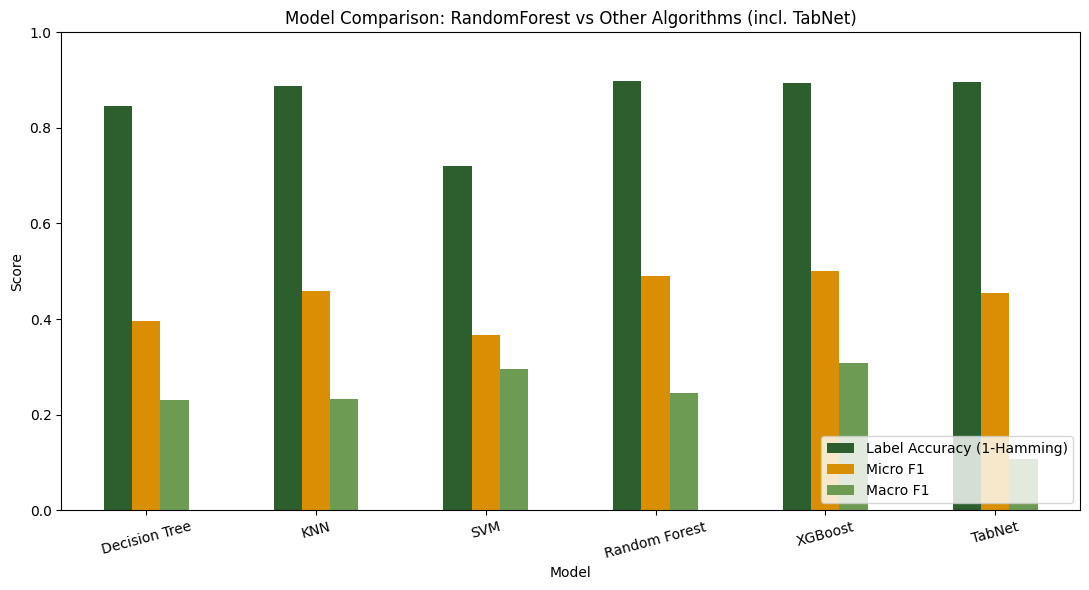

In [ ]:
comparison_df[['Label Accuracy (1-Hamming)', 'Micro F1', 'Macro F1']].plot(
    kind='bar', figsize=(11, 6), color=['#2C5F2D', '#D98E04', '#6E9B54']
)
plt.title('Model Comparison: RandomForest vs Other Algorithms (incl. TabNet)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 9. Bonus: Enriching with `Final_Integrated_Dataset.csv`
The integrated dataset has satellite/weather features (temperature, rainfall, humidity, soil pH, vegetation indices) for ~98 points concentrated in a small area (western UP / Haryana belt). We spatially match each point to its nearest region in the base crop dataset (by lat/long) to see which regions it overlaps with, and to build an environment-enriched feature table for that area.

In [ ]:
def nearest_region(lat, lon, ref_df):
    dist = np.sqrt((ref_df['Latitude'] - lat)**2 + (ref_df['Longitude'] - lon)**2)
    idx = dist.idxmin()
    return idx, dist.min()

matches = env_df.apply(lambda r: nearest_region(r['Latitude'], r['Longitude'], crop_df), axis=1)
env_df['match_idx']  = [m[0] for m in matches]
env_df['match_dist']  = [m[1] for m in matches]

# keep only reasonably close matches (~0.5 degrees ≈ 55km)
env_matched = env_df[env_df['match_dist'] < 0.5].copy()
env_matched['Address'] = crop_df.loc[env_matched['match_idx'], 'Address'].values
env_matched['Crop']    = crop_df.loc[env_matched['match_idx'], 'Crop'].values

print(f"{len(env_matched)}/{len(env_df)} points matched to a nearby region:")
print(env_matched['Address'].value_counts())

ENV_FEATURES = ['Soil_pH','Temperature','Humidity','Rainfall','WindSpeed',
                 'SurfaceSoilWetness','RootSoilWetness','EVI','NDVI','NDWI']
env_matched[['Address'] + ENV_FEATURES].groupby('Address').mean()


97/97 points matched to a nearby region:
Address
Muzaffarnagar, Uttar Pradesh    45
Shamli, Uttar Pradesh           41
Bijnor, Uttar Pradesh            8
Karnal, Haryana                  2
Meerut, Uttar Pradesh            1
Name: count, dtype: int64


,Soil_pH,Temperature,Humidity,Rainfall,WindSpeed,SurfaceSoilWetness,RootSoilWetness,EVI,NDVI,NDWI
Address,,,,,,,,,,
"Bijnor, Uttar Pradesh",70.750000,24.083333,58.26,108.395,1.811667,0.5175,0.545,1.199409,0.416191,-0.435141
"Karnal, Haryana",71.000000,24.083333,58.26,108.395,1.811667,0.5175,0.545,1.972970,0.681802,-0.621373
"Meerut, Uttar Pradesh",72.000000,24.083333,58.26,108.395,1.811667,0.5175,0.545,1.666155,0.595382,-0.564635
"Muzaffarnagar, Uttar Pradesh",70.844444,24.083333,58.26,108.395,1.811667,0.5175,0.545,1.271287,0.491711,-0.488948
"Shamli, Uttar Pradesh",71.682927,24.083333,58.26,108.395,1.811667,0.5175,0.545,1.386351,0.513693,-0.501720


This confirms the overlap is limited to a handful of regions (Muzaffarnagar, Shamli, Bijnor, Karnal, Meerut), so it isn't enough coverage on its own to retrain the main multi-label model nationally — it's used here as a **supplementary regional weather profile** rather than the primary training signal. The base model in Section 6 (all 689 regions, soil composition only) remains the general-purpose recommender.

## 10. Save the Model

In [ ]:
joblib.dump(model, 'crop_recommendation_model.joblib')
joblib.dump(mlb, 'crop_label_binarizer.joblib')
print("Saved: crop_recommendation_model.joblib, crop_label_binarizer.joblib")

try:
    from google.colab import files
    files.download('crop_recommendation_model.joblib')
    files.download('crop_label_binarizer.joblib')
except ImportError:
    pass


Saved: crop_recommendation_model.joblib, crop_label_binarizer.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes / Limitations
- Base dataset is **region-level** (aggregated soil composition), not per-farm — so predictions are regional crop suitability, not a farm-specific recommendation.
- Some crop name fragments in the source data were malformed (parsing artifacts); the normalization step is best-effort — extend `SYNONYMS`/`JUNK` as needed.
- `MIN_COUNT` and the match-distance threshold in the bonus section are adjustable — lower `MIN_COUNT` to include more (rarer) crops at the cost of noisier labels.